# 🎧 RAG System — Cải tiến theo Review

**Các điểm đã được sửa so với phiên bản cũ:**
1. ✅ Tách block CONFIG rõ ràng, fallback local + auto detect cuda/cpu
2. ✅ `clean_vietnamese_text()` chỉ định nghĩa MỘT LẦN duy nhất ở Cell Shared Utils
3. ✅ Metadata dùng làm hard filter & rerank bonus (brand, price)
4. ✅ Dedup trong `retrieve_hybrid()` dùng `url` thay vì `original_content`
5. ✅ Benchmark reranker vs không reranker
6. ✅ Evaluation đúng chuẩn: Precision@5, HitRate@5, MRR, nDCG@5
7. ✅ Tách hàm rõ ràng: prepare → build → load → retrieve → rerank → evaluate
8. ✅ BM25 tokenize chuẩn PyVi
9. ✅ Thêm logging và kiểm tra lỗi
10. ✅ Chiến lược chunking: 1 sản phẩm = 1 document mặc định, chỉ chunk nếu review dài

## Cell 1 — Cài đặt thư viện

In [ ]:
# GIỮ NGUYÊN
!pip install faiss-cpu pyvi sentence-transformers rank-bm25 pandas numpy tqdm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 80.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 117.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 84.4 MB/s eta 0:00:00


In [ ]:
# GIỮ NGUYÊN
!pip install fastapi uvicorn nest_asyncio matplotlib seaborn -q
!pip install langchain langchain-community langchain-huggingface -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


## Cell 2 — CONFIG TẬP TRUNG (SỬA: Điểm 1)
> Gom toàn bộ path và device vào đây. Fallback local nếu không có Colab/Drive.

In [ ]:
import os
import torch
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# SỬA ĐIỂM 1: Auto detect môi trường (Colab vs local)
# ─────────────────────────────────────────────
try:
    from google.colab import drive
    IS_COLAB = True
    if not os.path.exists('/content/drive'):
        drive.mount('/content/drive')
    DRIVE_FOLDER = '/content/drive/MyDrive/RAG_Data_XuanVu'
    print("[INFO] Đang chạy trên Google Colab — Drive đã mount")
except ImportError:
    IS_COLAB = False
    DRIVE_FOLDER = './RAG_Data_XuanVu'
    print("[INFO] Đang chạy LOCAL — dùng thư mục local:", DRIVE_FOLDER)

os.makedirs(DRIVE_FOLDER, exist_ok=True)

# ─────────────────────────────────────────────
# SỬA ĐIỂM 1: Auto detect cuda/cpu
# ─────────────────────────────────────────────
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🖥️  Device: {DEVICE.upper()} {'(GPU)' if DEVICE == 'cuda' else '(CPU — chậm hơn nhưng vẫn chạy được)'}")

# ─────────────────────────────────────────────
# CẤU HÌNH ĐƯỜNG DẪN — chỉ sửa ở đây nếu cần
# ─────────────────────────────────────────────
RAW_DATA_PATH   = f"{DRIVE_FOLDER}/full_xuanvu_database.csv"
INDEX_FOLDER    = f"{DRIVE_FOLDER}/faiss_index_v2"
DOCSTORE_PATH   = f"{DRIVE_FOLDER}/docstore_v2.pkl"
EVAL_RESULT_PATH = f"{DRIVE_FOLDER}/eval_results.csv"

# ─────────────────────────────────────────────
# CẤU HÌNH MODEL
# ─────────────────────────────────────────────
# EMBED_MODEL_NAME  = 'keepitreal/vietnamese-sbert'
# RERANK_MODEL_NAME = 'cross-encoder/mmarco-mMiniLMv2-L12-H384-v1'
EMBED_MODEL_NAME = 'bkai-foundation-models/vietnamese-bi-encoder'
RERANK_MODEL_NAME = 'BAAI/bge-reranker-v2-m3'

# ─────────────────────────────────────────────
# CẤU HÌNH RETRIEVAL
# ─────────────────────────────────────────────
TOP_K_RETRIEVE = 25
TOP_K_FINAL    = 5

# ─────────────────────────────────────────────
# CẤU HÌNH CHUNKING (Điểm 10)
# ─────────────────────────────────────────────
CHUNK_IF_LONGER_THAN = 1000  # Chỉ chunk nếu review dài hơn N ký tự
CHUNK_SIZE    = 500
CHUNK_OVERLAP = 50

# ─────────────────────────────────────────────
# CẤU HÌNH BRAND
# ─────────────────────────────────────────────
BRAND_KEYWORDS = [
    "sony", "jbl", "sennheiser", "soundpeats", "anker", "edifier",
    "final", "fiio", "moondrop", "soundmagic", "akg", "bose",
    "apple", "marshall", "hifiman",
    "thieaudio", "beyerdynamic", "audio-technica", "audiotechnica",
    "unique melody", "pwaudio", "pw audio", "monster", "koss",
    "hifiman", "final", "fiio", "moondrop", "tangzu", "hiby",
    "dekoni", "hidizs", "campfire", "64 audio", "64audio",
    "empire ears", "meze", "grado", "focal", "audeze",
    "tin hifi", "tinhifi", "simgot", "dunu", "kinera",
    "letshuoer", "truthear", "7hz", "tripowin", "kz",
    "cca", "tanchjim", "yanyin", "softears"
]

print("\n[INFO] Config khởi tạo thành công!")
print(f"   RAW_DATA : {RAW_DATA_PATH}")
print(f"   INDEX    : {INDEX_FOLDER}")
print(f"   DOCSTORE : {DOCSTORE_PATH}")

[INFO] Đang chạy trên Google Colab — Drive đã mount
🖥️  Device: CUDA (GPU)

[INFO] Config khởi tạo thành công!
   RAW_DATA : /content/drive/MyDrive/RAG_Data_XuanVu/full_xuanvu_database.csv
   INDEX    : /content/drive/MyDrive/RAG_Data_XuanVu/faiss_index_v2
   DOCSTORE : /content/drive/MyDrive/RAG_Data_XuanVu/docstore_v2.pkl


## Cell 3 — SHARED UTILS (SỬA: Điểm 2 + 9)
> `clean_vietnamese_text()` chỉ định nghĩa một lần tại đây. Tất cả cell sau đều import từ đây.

In [ ]:
import re
import pandas as pd
import numpy as np
from pyvi import ViTokenizer

# ─────────────────────────────────────────────
# SỬA ĐIỂM 2: Hàm duy nhất, dùng chung cho build index / query / evaluation
# ─────────────────────────────────────────────
def clean_vietnamese_text(text):
    """Chuẩn hoá + tokenize tiếng Việt (PyVi). Dùng chung toàn bộ pipeline."""
    if not isinstance(text, str):
        return ""
    text = re.sub(r'[\r\n\t]+', ' ', text)
    text = re.sub(r'[^\w\s.,?!/]', '', text)
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return ViTokenizer.tokenize(text)

def extract_brand(text):
    """Trích thương hiệu từ tên sản phẩm."""
    text_lower = str(text).lower()
    for b in BRAND_KEYWORDS:
        if b in text_lower:
            return b
    return "khác"

def clean_price(price_str):
    """Chuyển chuỗi giá về số nguyên."""
    if pd.isna(price_str):
        return 0
    price_num = re.sub(r'[^\d]', '', str(price_str))
    return int(price_num) if price_num else 0

# ─────────────────────────────────────────────
# SỬA ĐIỂM 9: Helper kiểm tra guard chung
# ─────────────────────────────────────────────
def check_file_exists(path, label="File"):
    """Kiểm tra file tồn tại, in thông báo rõ ràng."""
    if not os.path.exists(path):
        print(f"[ERROR] KHÔNG TÌM THẤY {label}: {path}")
        return False
    print(f"[INFO] {label} tồn tại: {path}")
    return True

def check_metadata_fields(doc, required_fields):
    """Kiểm tra metadata của document có đủ trường không."""
    missing = [f for f in required_fields if f not in doc.metadata]
    if missing:
        print(f"[WARNING]  Metadata thiếu trường: {missing}")
        return False
    return True

print("[INFO] Shared utils đã sẵn sàng (clean_vietnamese_text, extract_brand, clean_price, guards)")

[INFO] Shared utils đã sẵn sàng (clean_vietnamese_text, extract_brand, clean_price, guards)


In [ ]:
def dedup_by_url(docs):
    """
    Giữ lại 1 document đại diện cho mỗi URL (chunk tốt nhất = chunk đầu tiên sau rerank).
    Tránh cùng 1 sản phẩm chiếm nhiều slot trong Top K.
    """
    seen_urls = {}
    for doc in docs:
        url = doc.metadata.get('url', doc.metadata.get('product_name', ''))
        if url not in seen_urls:
            seen_urls[url] = doc
    result = list(seen_urls.values())
    return result

## Cell 4 — Web Scraper (GIỮ NGUYÊN — commented out)

In [ ]:
# GIỮ NGUYÊN — Web scraper (bỏ comment để chạy lại nếu cần cào dữ liệu mới)

# import requests
# from bs4 import BeautifulSoup
# import time
# import random
# import concurrent.futures

# BASE_DOMAIN = "https://tainghe.com.vn"
# HEADERS = {
#     "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
#     "Accept-Language": "vi-VN,vi;q=0.9,en-US;q=0.8,en;q=0.7",
# }
# MAX_THREADS = 20

# def get_all_subcategories():
#     print("--- ĐANG LỌC DANH MỤC TRÊN TRANG CHỦ ---")
#     sub_categories = set()
#     try:
#         response = requests.get(BASE_DOMAIN, headers=HEADERS, timeout=10)
#         soup = BeautifulSoup(response.text, 'html.parser')
#         menu_items = soup.find_all('a')
#         for item in menu_items:
#             href = item.get('href', '')
#             if href.endswith('.html') and not href.startswith('http'):
#                 full_link = BASE_DOMAIN + href if href.startswith('/') else BASE_DOMAIN + '/' + href
#                 if any(keyword in href for keyword in ['tai-nghe', 'may-nghe-nhac', 'dac-amp', 'loa', 'phu-kien', 'hi-end-cables']):
#                     sub_categories.add(full_link)
#         print(f"[OK] Đã chốt được {len(sub_categories)} link danh mục.")
#         return list(sub_categories)
#     except Exception as e:
#         print(f"[LỖI] Lọc danh mục thất bại: {e}")
#         return []

# def get_product_links_from_category(category_url, max_pages_per_cat=50):
#     product_links = set()
#     for page in range(1, max_pages_per_cat + 1):
#         url = f"{category_url}?page={page}"
#         try:
#             response = requests.get(url, headers=HEADERS, timeout=10)
#             soup = BeautifulSoup(response.text, 'html.parser')
#             items = soup.find_all('a', class_='p-name')
#             if not items:
#                 break
#             for item in items:
#                 link = item.get('href')
#                 if link:
#                     full_link = link if "http" in link else BASE_DOMAIN + link
#                     product_links.add(full_link)
#             time.sleep(random.uniform(0.5, 1.5))
#         except Exception as e:
#             break
#     return list(product_links)

# def fetch_product_details(url):
#     try:
#         response = requests.get(url, headers=HEADERS, timeout=15)
#         response.raise_for_status()
#         soup = BeautifulSoup(response.text, 'html.parser')
#         name_tag = soup.find('h1', id='detail-name')
#         name = name_tag.text.strip() if name_tag else "Unknown"
#         price_tag = soup.find('span', class_='price_config')
#         price = price_tag.text.strip() if price_tag else "Contact"
#         brand = "Unknown"
#         candidates = soup.find_all(lambda t: t.name in ['li', 'p', 'div', 'tr', 'span', 'b', 'strong']
#                                    and t.get_text()
#                                    and 'thương hiệu' in t.get_text().lower())
#         if candidates:
#             candidates_sorted = sorted(candidates, key=lambda t: len(t.get_text(strip=True)))
#             for tag in candidates_sorted:
#                 text = tag.get_text(separator=' ', strip=True)
#                 match = re.search(r'thương\s*hiệu\s*[:\-]?\s*(.+)', text, re.IGNORECASE)
#                 if match:
#                     extracted = match.group(1).strip()
#                     if extracted and len(extracted) < 30:
#                         brand = extracted
#                         break
#         content_tag = soup.find('div', class_='emtry_content')
#         content = content_tag.text.strip() if content_tag else ""
#         time.sleep(random.uniform(1.0, 2.5))
#         if content and name != "Unknown":
#             print(f"[XONG] {name[:30]:<30} | Hãng: {brand:<15} | Giá: {price}")
#             return {"url": url, "product_name": name, "brand": brand, "price": price, "review_content": content}
#         return None
#     except Exception as e:
#         print(f"[LỖI] {url} -> {e}")
#         return None

# def run_full_scraper():
#     start_time = time.time()
#     categories = get_all_subcategories()
#     if not categories:
#         return
#     print(f"\n--- BƯỚC 2: ĐANG GOM LINK TỪ {len(categories)} DANH MỤC ---")
#     all_product_links = set()
#     for i, cat_url in enumerate(categories):
#         print(f"Đang lật trang danh mục [{i+1}/{len(categories)}]: {cat_url}")
#         links = get_product_links_from_category(cat_url)
#         all_product_links.update(links)
#     product_links_list = list(all_product_links)
#     print(f"\n✅ TỔNG CỘNG ĐÃ GOM ĐƯỢC: {len(product_links_list)} LINK SẢN PHẨM KHÁC NHAU.")
#     print(f"\n--- BƯỚC 3: BẮT ĐẦU BÓC TÁCH CHI TIẾT BẰNG {MAX_THREADS} THREADS ---")
#     final_data = []
#     with concurrent.futures.ThreadPoolExecutor(max_workers=MAX_THREADS) as executor:
#         future_to_url = {executor.submit(fetch_product_details, url): url for url in product_links_list}
#         for future in concurrent.futures.as_completed(future_to_url):
#             data = future.result()
#             if data:
#                 final_data.append(data)
#     drive_save_path = RAW_DATA_PATH
#     df = pd.DataFrame(final_data)
#     df.to_csv(drive_save_path, index=False, encoding='utf-8-sig')
#     end_time = time.time()
#     print(f"\nHOÀN THÀNH CÀO DỮ LIỆU! {len(final_data)} sản phẩm — {round((end_time - start_time)/60, 2)} phút.")

# if __name__ == "__main__":
#     run_full_scraper()

## Cell 5 — EDA (GIỮ NGUYÊN)

 BẮT ĐẦU KHÁM PHÁ DỮ LIỆU (EDA)
[INFO] RAW_DATA tồn tại: /content/drive/MyDrive/RAG_Data_XuanVu/full_xuanvu_database.csv
   Tổng số sản phẩm: 2350
   Số thương hiệu nhận diện được: 44


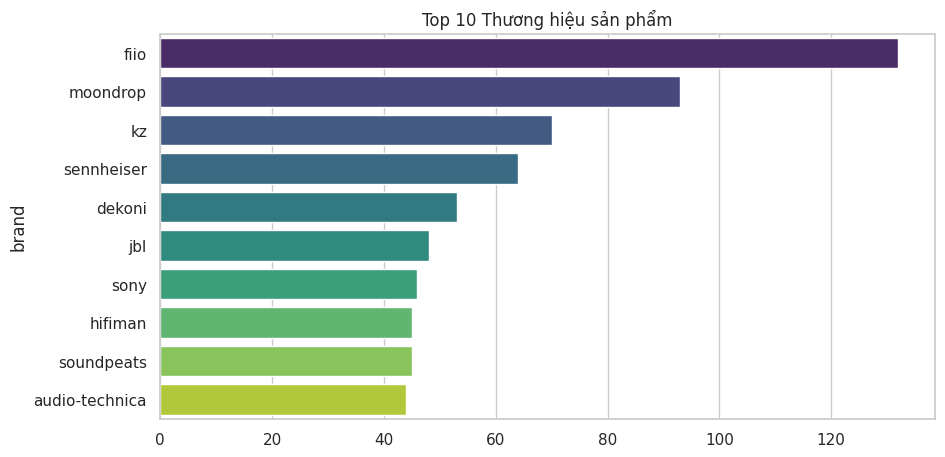

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

def run_eda():
    print(" BẮT ĐẦU KHÁM PHÁ DỮ LIỆU (EDA)")
    if not check_file_exists(RAW_DATA_PATH, "RAW_DATA"):
        return
    df = pd.read_csv(RAW_DATA_PATH)
    df['brand'] = df['product_name'].apply(extract_brand)
    print(f"   Tổng số sản phẩm: {len(df)}")
    print(f"   Số thương hiệu nhận diện được: {df[df['brand'] != 'khác']['brand'].nunique()}")
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 5))
    top_brands = df[df['brand'] != 'khác']['brand'].value_counts().head(10)
    sns.barplot(x=top_brands.values, y=top_brands.index, hue=top_brands.index, palette='viridis', legend=False)
    plt.title('Top 10 Thương hiệu sản phẩm')
    plt.show()

run_eda()

## Cell 6 — PREPARE DATA (SỬA: Điểm 7 + 10)
> Tách riêng bước chuẩn bị dữ liệu. Chiến lược: 1 sản phẩm = 1 document, chỉ chunk nếu review quá dài.

In [ ]:
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from tqdm.auto import tqdm

def prepare_data():
    """
    SỬA ĐIỂM 7: Tách riêng bước prepare.
    SỬA ĐIỂM 10: 1 sản phẩm = 1 document mặc định.
                 Chỉ chunk nếu review_content > CHUNK_IF_LONGER_THAN ký tự.
    """
    if not check_file_exists(RAW_DATA_PATH, "RAW_DATA"):
        return None

    df = pd.read_csv(RAW_DATA_PATH)
    print(f"📂 Đọc dữ liệu: {len(df)} sản phẩm")
    print(f"   Các cột: {list(df.columns)}")

    # SỬA ĐIỂM 9: Kiểm tra dữ liệu rỗng
    required_cols = ['product_name', 'review_content', 'price', 'url']
    for col in required_cols:
        if col not in df.columns:
            print(f"[ERROR] Thiếu cột bắt buộc: {col}")
            return None
    df = df.dropna(subset=['product_name', 'review_content'])
    print(f"   Sau khi lọc NaN: {len(df)} sản phẩm hợp lệ")

    df['price_num'] = df['price'].apply(clean_price)
    df['brand']     = df['product_name'].apply(extract_brand)

    # Splitter dùng khi review quá dài
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=CHUNK_SIZE,
        chunk_overlap=CHUNK_OVERLAP,
        separators=["\n\n", "\n", ".", " "]
    )

    documents = []
    n_chunked = 0

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Preparing documents"):
        raw_name    = str(row['product_name'])
        raw_review  = str(row['review_content'])
        raw_price   = str(row['price'])           # giá dạng chuỗi gốc, dễ đọc
        raw_brand   = str(row['brand'])
        price_num   = row['price_num']
        url         = str(row.get('url', ''))

        # ── THAY ĐỔI CHÍNH ──────────────────────────────────────────────
        # Nhúng brand + price vào page_content để FAISS & BM25 đều thấy.
        # Cấu trúc rõ ràng giúp BM25 match keyword đúng hơn.
        structured_raw = (
            f"Sản phẩm: {raw_name}. "
            f"Thương hiệu: {raw_brand}. "
            f"Giá: {raw_price}. "
            f"{raw_review}"
        )
        # ────────────────────────────────────────────────────────────────
        metadata_base = {
            "product_name":    raw_name,
            "brand":           raw_brand,
            "price":           price_num,
            "url":             url,
            "original_content": structured_raw   # lưu bản gốc chưa clean để hiển thị
        }

        # SỬA ĐIỂM 10: Chỉ chunk nếu review quá dài
        if len(raw_review) > CHUNK_IF_LONGER_THAN:
            n_chunked += 1
            raw_chunks = text_splitter.split_text(structured_raw)
            for chunk in raw_chunks:
                # SỬA ĐIỂM 2: Dùng clean_vietnamese_text chung
                clean_chunk = clean_vietnamese_text(chunk)
                if clean_chunk.strip():
                    documents.append(Document(
                        page_content=clean_chunk,
                        metadata={**metadata_base, "original_content": chunk}
                    ))
        else:
            # 1 sản phẩm = 1 document
            clean_doc = clean_vietnamese_text(structured_raw)
            if clean_doc.strip():
                documents.append(Document(
                    page_content=clean_doc,
                    metadata=metadata_base
                ))

    # SỬA ĐIỂM 9: Log sau khi chuẩn bị
    print(f"\n[INFO] Chuẩn bị xong:")
    print(f"   Tổng documents: {len(documents)}")
    print(f"   Sản phẩm được chunk (review dài): {n_chunked}")
    print(f"   Sản phẩm giữ nguyên (1 doc): {len(df) - n_chunked}")

    if documents:
        sample = documents[0]
        print(f"\n   [SAMPLE page_content đầu tiên]:")
        print(f"   {sample.page_content[:200]}...")
        print(f"   metadata keys: {list(sample.metadata.keys())}")

    return documents

print("[INFO] Hàm prepare_data() đã định nghĩa.")

[INFO] Hàm prepare_data() đã định nghĩa.


## Cell 7 — BUILD INDEX (SỬA: Điểm 7 + 9)

In [ ]:
import pickle
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from sentence_transformers import SentenceTransformer

def build_index(documents):
    """
    SỬA ĐIỂM 7: Tách riêng bước build index.
    SỬA ĐIỂM 9: Log chi tiết từng bước.
    """
    if documents is None or len(documents) == 0:
        print("[ERROR] Không có documents để build index!")
        return None

    print(f"[RUNNING] Bắt đầu build index với {len(documents)} documents...")

    # SỬA ĐIỂM 1: Dùng DEVICE từ config
    lc_embedder = HuggingFaceEmbeddings(
        model_name=EMBED_MODEL_NAME,
        model_kwargs={'device': DEVICE}
    )

    texts     = [doc.page_content for doc in documents]
    metadatas = [doc.metadata for doc in documents]

    print(f"   Đang encode {len(texts)} texts bằng {DEVICE.upper()}...")
    fast_embedder = SentenceTransformer(EMBED_MODEL_NAME, device=DEVICE)
    batch = 256 if DEVICE == 'cuda' else 32
    embeddings_matrix = fast_embedder.encode(texts, batch_size=batch, show_progress_bar=True)

    print("\n[RUNNING] Đóng gói vào FAISS...")
    text_embedding_pairs = list(zip(texts, embeddings_matrix.tolist()))
    vector_store = FAISS.from_embeddings(
        text_embeddings=text_embedding_pairs,
        embedding=lc_embedder,
        metadatas=metadatas
    )

    print(f"[INFO] Lưu index vào: {INDEX_FOLDER}")
    vector_store.save_local(INDEX_FOLDER)
    with open(DOCSTORE_PATH, "wb") as f:
        pickle.dump(documents, f)

    print(f"[INFO] Build index hoàn thành! ({len(documents)} vectors)")
    return vector_store

print("[INFO] Hàm build_index() đã định nghĩa.")

[INFO] Hàm build_index() đã định nghĩa.


## Cell 8 — LOAD INDEX (SỬA: Điểm 7 + 9)

In [ ]:
from rank_bm25 import BM25Okapi
from sentence_transformers import CrossEncoder

def load_index():
    """
    SỬA ĐIỂM 7: Tách riêng bước load.
    SỬA ĐIỂM 9: Guard kiểm tra file tồn tại.
    """
    if not check_file_exists(INDEX_FOLDER, "INDEX_FOLDER"):
        return None, None, None, None
    if not check_file_exists(DOCSTORE_PATH, "DOCSTORE"):
        return None, None, None, None

    print("\n⏳ Đang tải Embedding model...")
    embeddings = HuggingFaceEmbeddings(
        model_name=EMBED_MODEL_NAME,
        model_kwargs={'device': DEVICE}  # SỬA ĐIỂM 1
    )
    vector_store = FAISS.load_local(INDEX_FOLDER, embeddings, allow_dangerous_deserialization=True)

    with open(DOCSTORE_PATH, "rb") as f:
        all_docs = pickle.load(f)

    # SỬA ĐIỂM 9: Kiểm tra metadata đủ trường
    REQUIRED_FIELDS = ['product_name', 'brand', 'price', 'url', 'original_content']
    bad_docs = [i for i, d in enumerate(all_docs) if not check_metadata_fields(d, REQUIRED_FIELDS)]
    if bad_docs:
        print(f"[WARNING]  {len(bad_docs)} documents thiếu metadata — có thể ảnh hưởng reranking")
    else:
        print(f"[INFO] Tất cả {len(all_docs)} documents có đủ metadata")

    # SỬA ĐIỂM 8: BM25 tokenize chuẩn PyVi (page_content đã được tokenize khi build)
    print("[RUNNING] Đang khởi tạo BM25 (dùng page_content đã tokenize PyVi)...")
    tokenized_corpus = [doc.page_content.split() for doc in all_docs]
    bm25 = BM25Okapi(tokenized_corpus)
    print(f"   BM25 vocab size: {len(bm25.idf)} terms")

    print("[RUNNING] Đang tải Reranker...")
    reranker = CrossEncoder(RERANK_MODEL_NAME, device=DEVICE)  # SỬA ĐIỂM 1

    print(f"\n[INFO] Hệ thống Retrieval sẵn sàng! ({len(all_docs)} docs trong index)")
    return vector_store, bm25, reranker, all_docs

print("[INFO] Hàm load_index() đã định nghĩa.")

[INFO] Hàm load_index() đã định nghĩa.


## Cell 9 — AUTO INIT: Build nếu chưa có, Load nếu đã có (SỬA: Điểm 7)

In [ ]:
index_exists = os.path.exists(INDEX_FOLDER) and os.path.exists(DOCSTORE_PATH)

if not index_exists:
    print("🚀 Chưa có Index — bắt đầu build từ đầu...")
    all_docs_prepared = prepare_data()
    vector_store = build_index(all_docs_prepared)
    # Load lại sau khi build để có bm25 & reranker
    vector_store, bm25, reranker, all_docs = load_index()
else:
    print("ℹ️  Index đã tồn tại — load trực tiếp...")
    vector_store, bm25, reranker, all_docs = load_index()

🚀 Chưa có Index — bắt đầu build từ đầu...
[INFO] RAW_DATA tồn tại: /content/drive/MyDrive/RAG_Data_XuanVu/full_xuanvu_database.csv
📂 Đọc dữ liệu: 2350 sản phẩm
   Các cột: ['url', 'product_name', 'brand', 'price', 'review_content']
   Sau khi lọc NaN: 2350 sản phẩm hợp lệ


Preparing documents:   0%|          | 0/2350 [00:00<?, ?it/s]


[INFO] Chuẩn bị xong:
   Tổng documents: 18494
   Sản phẩm được chunk (review dài): 1579
   Sản phẩm giữ nguyên (1 doc): 771

   [SAMPLE page_content đầu tiên]:
   sản_phẩm đệm pad tai_nghe sony mdr 10rbt . thương_hiệu sony . giá 250.000 đ . đệm thay_thế cho tai_nghe sony mdr10rbt , mdr10rnc , mdr10r các tai_nghe hỗ_trợ phù_hợp với tai_nghe sony mdr10rbt , mdr10...
   metadata keys: ['product_name', 'brand', 'price', 'url', 'original_content']
[RUNNING] Bắt đầu build index với 18494 documents...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]


[INFO] Hệ thống Retrieval sẵn sàng! (18494 docs trong index)


## Cell 10 — RETRIEVE DENSE (SỬA: Điểm 7)

In [ ]:
def retrieve_dense(query, vector_store, k=TOP_K_RETRIEVE):
    clean_q = clean_vietnamese_text(query)
    # Lấy k*4 để sau dedup vẫn còn đủ k docs
    raw = vector_store.similarity_search(clean_q, k=k * 4)
    return dedup_by_url(raw)[:k]

print("[INFO] Hàm retrieve_dense() đã định nghĩa.")

[INFO] Hàm retrieve_dense() đã định nghĩa.


## Cell 11 — RETRIEVE HYBRID (SỬA: Điểm 4 + 7 + 9)

In [ ]:
def retrieve_hybrid(query, vector_store, bm25, all_docs, k_retrieve=50, verbose=False):
    """
    SỬA ĐIỂM 4: Dedup dùng 'url' thay vì 'original_content'.
    SỬA ĐIỂM 7: Tách hàm riêng (chưa có reranking — xem rerank_candidates).
    SỬA ĐIỂM 9: Log số candidate dense/sparse.
    SỬA LỖI HIỆU SUẤT: Đổi k_retrieve mặc định thành 50 (Lấy Rộng) để Reranker có đủ ứng viên chấm điểm thay vì chỉ lấy Top 5.
    """
    # SỬA ĐIỂM 2: Dùng clean_vietnamese_text chung
    clean_q = clean_vietnamese_text(query)

    # Dense Search
    dense_docs = vector_store.similarity_search(clean_q, k=k_retrieve)

    # SỬA ĐIỂM 8: BM25 query cũng được tokenize chuẩn PyVi
    tokenized_query = clean_q.split()
    sparse_docs = bm25.get_top_n(tokenized_query, all_docs, n=k_retrieve)

    if verbose:
        print(f"   Dense candidates : {len(dense_docs)}")
        print(f"   Sparse candidates: {len(sparse_docs)}")

    # SỬA ĐIỂM 4: Dedup dùng URL (key duy nhất) thay vì original_content
    unique_docs = {}
    for doc in (dense_docs + sparse_docs):
        url_key = doc.metadata.get('url', doc.metadata.get('original_content', ''))
        if url_key not in unique_docs:
            unique_docs[url_key] = doc

    all_candidates = list(unique_docs.values())

    if verbose:
        print(f"   Sau dedup        : {len(all_candidates)} unique candidates")

    return all_candidates

print("✅ Hàm retrieve_hybrid() đã định nghĩa.")

✅ Hàm retrieve_hybrid() đã định nghĩa.


## Cell 12 — RERANK + METADATA BONUS (SỬA: Điểm 3 + 7 + 9)

In [ ]:
def rerank_candidates(query, candidates, reranker, top_k=TOP_K_FINAL, verbose=False):
    """
    SỬA ĐIỂM 3: Sau reranking, cộng bonus brand/price từ metadata.
    SỬA ĐIỂM 7: Tách hàm riêng.
    SỬA ĐIỂM 9: Log điểm rerank + bonus.
    """
    if not candidates:
        print("⚠️  Không có candidates để rerank!")
        return []

    pairs = [[query, doc.metadata.get('original_content', doc.page_content)] for doc in candidates]
    rerank_scores = reranker.predict(pairs)

    # SỬA ĐIỂM 3: Tính metadata bonus
    query_lower = query.lower()
    for i, (score, doc) in enumerate(zip(rerank_scores, candidates)):
        bonus = 0.0

        # Brand bonus: cộng thêm nếu query đề cập đúng brand
        doc_brand = doc.metadata.get('brand', '').lower()
        if doc_brand and doc_brand != 'khác' and doc_brand in query_lower:
            bonus += 0.5

        # Price filter: trừ điểm nếu query có "dưới X triệu" mà giá sản phẩm cao hơn
        price_match = re.search(r'dưới\s*(\d+)\s*triệu', query_lower)
        if price_match:
            max_price = int(price_match.group(1)) * 1_000_000
            doc_price = doc.metadata.get('price', 0)
            if doc_price > max_price:
                bonus -= 1.0  # Phạt nếu lệch giá

        candidates[i].metadata['rerank_score'] = float(score) + bonus
        candidates[i].metadata['rerank_raw']   = float(score)
        candidates[i].metadata['meta_bonus']   = bonus

    # Sort toàn bộ trước
    sorted_all = sorted(candidates, key=lambda x: x.metadata['rerank_score'], reverse=True)
    # Dedup theo URL TRƯỚC khi cắt top_k — áp dụng cho mọi nơi gọi hàm này
    deduped = dedup_by_url(sorted_all)[:top_k]

    if verbose:
        print(f"   Rerank hoàn thành — Top {top_k} kết quả (sau dedup):")
        for d in deduped:
            print(f"     [{d.metadata['rerank_score']:.3f}] (raw={d.metadata['rerank_raw']:.3f}, "
                  f"bonus={d.metadata['meta_bonus']:+.1f}) {d.metadata['product_name'][:40]}")

    return deduped

print("✅ Hàm rerank_candidates() đã định nghĩa.")

✅ Hàm rerank_candidates() đã định nghĩa.


## Cell 13 — RAG ANSWER (GIỮ NGUYÊN logic, cập nhật gọi hàm mới)

In [ ]:
def rag_answer(query, vector_store, bm25, reranker, all_docs, retrieval_mode="hybrid"):
    """Pipeline RAG đầy đủ. GIỮ NGUYÊN cấu trúc output, cập nhật gọi hàm mới."""
    if retrieval_mode == "hybrid":
        candidates = retrieve_hybrid(query, vector_store, bm25, all_docs)
        context_docs = rerank_candidates(query, candidates, reranker)
    else:
        context_docs = retrieve_dense(query, vector_store, k=TOP_K_FINAL)

    formatted_contexts = []
    for d in context_docs:
        product = d.metadata['product_name']
        price   = f"{d.metadata['price']:,} VNĐ" if d.metadata['price'] > 0 else "Liên hệ"
        chunk_str = f"Sản phẩm: {product} (Giá: {price})\nThông tin:\n{d.metadata['original_content']}"
        formatted_contexts.append(chunk_str)

    context_text = "\n" + "="*40 + "\n" + "\n".join(formatted_contexts) + "\n" + "="*40
    return {
        "answer":  "[Output từ LLM]",
        "context": context_text,
        "sources": [d.metadata.get('url', 'N/A') for d in context_docs]
    }

print("✅ Hàm rag_answer() đã định nghĩa.")

✅ Hàm rag_answer() đã định nghĩa.


## Cell 14 — INTERACTIVE SESSION (GIỮ NGUYÊN)

In [ ]:
def run_interactive_session():
    # GIỮ NGUYÊN toàn bộ logic
    if vector_store is None:
        print("❌ Chưa load index. Hãy chạy Cell 9 trước.")
        return
    while True:
        user_query = input("  Nhập câu hỏi tìm kiếm (hoặc gõ 'exit' để thoát): ")
        if user_query.lower() in ['exit', 'quit', 'thoát']:
            print("  Tạm biệt!")
            break
        if not user_query.strip():
            continue
        print("\n  Đang tìm kiếm...")
        candidates = retrieve_hybrid(user_query, vector_store, bm25, all_docs, verbose=True)
        results    = rerank_candidates(user_query, candidates, reranker, verbose=True)

        print(f"\n  TÌM THẤY {len(results)} KẾT QUẢ TỐT NHẤT:")
        for idx, doc in enumerate(results, 1):
            product   = doc.metadata.get('product_name', 'N/A')
            price     = doc.metadata.get('price', 0)
            price_str = f"{price:,} VNĐ" if price > 0 else "Liên hệ"
            score     = doc.metadata.get('rerank_score', 0)
            content   = doc.metadata.get('original_content', '')
            print(f"[{idx}] SẢN PHẨM: {product}")
            print(f"    💰 Giá: {price_str}")
            print(f"    📈 Điểm Rerank: {score:.2f} (Càng cao càng sát nghĩa)")
            print(f"    📄 Trích đoạn: {content[:200]}...")
            print("-" * 40)

# Bỏ comment dòng dưới để chạy interactive
run_interactive_session()

  Nhập câu hỏi tìm kiếm (hoặc gõ 'exit' để thoát): Tìm cho tôi dây cáp PWaudio No.5 Đồng OCC Litz

  Đang tìm kiếm...
   Dense candidates : 50
   Sparse candidates: 50
   Sau dedup        : 60 unique candidates
   Rerank hoàn thành — Top 5 kết quả (sau dedup):
     [1.436] (raw=0.936, bonus=+0.5) PWaudio No.5 Đồng OCC Litz
     [1.147] (raw=0.647, bonus=+0.5) PWAudio Entry Level The Flash Copper
     [1.086] (raw=0.586, bonus=+0.5) PWAudio Century Series The 1960s
     [1.060] (raw=0.560, bonus=+0.5) PWAudio Century Series The 1960s 4wired
     [0.950] (raw=0.950, bonus=+0.0) PW Audio Anniversary series No.5 8wired

  TÌM THẤY 5 KẾT QUẢ TỐT NHẤT:
[1] SẢN PHẨM: PWaudio No.5 Đồng OCC Litz
    💰 Giá: 3,990,000 VNĐ
    📈 Điểm Rerank: 1.44 (Càng cao càng sát nghĩa)
    📄 Trích đoạn: Bao bì & Phụ kiện cáp PWaudio No.5 Đồng OCC Litz

Không hổ danh là dòng sản phẩm cao cấp của PWAudio, No.5 đi kèm với một hộp đựng bằng bìa cứng, mặt trên in logo thương hiệu trông khá sang trọng và b...
-------

## Cell 15 — EVALUATION ĐÚNG CHUẨN (SỬA: Điểm 5 + 6)
> Thay `score_mock` bằng các metric chuẩn: Precision@5, HitRate@5, MRR, nDCG@5.
> Benchmark cả hai cấu hình: Dense vs Hybrid+Rerank.

In [ ]:
import math

TEST_QUERIES = [
    # 1. Truy vấn khớp chính xác tên sản phẩm (Kiểm tra Keyword/BM25)
    {
        "query": "Tìm cho tôi dây cáp PWaudio No.5 Đồng OCC Litz",
        "relevant_urls": ["https://tainghe.com.vn/pwaudio-no-5-dong-occ-litz.html"],
        "relevant_keywords": ["no.5", "đồng occ", "litz"]
    },

    # 2. Truy vấn chứa điều kiện về giá và thương hiệu (Kiểm tra logic Metadata Bonus đã viết)
    {
        "query": "Tìm dây cáp tai nghe PWAudio giá dưới 5 triệu",
        "relevant_urls": [], # Bỏ trống URL để code dùng keyword fallback
        "relevant_keywords": ["pwaudio", "dây cáp", "cáp tai nghe"]
    },

    # 3. Truy vấn tìm theo dòng sản phẩm (Series) (Kiểm tra Vector Search & Reranker)
    {
        "query": "Các dòng cáp Century Series The 1960s của PWAudio có tốt không?",
        "relevant_urls": ["https://tainghe.com.vn/pwaudio-century-series-the-1960s-chinh-hang.html",
                          "https://tainghe.com.vn/pwaudio-monile-mkii-ft.60s.html"],
        "relevant_keywords": ["century series", "1960s", "ft.60s"]
    },

    # 4. Truy vấn sai chính tả nhẹ / Dùng từ đồng nghĩa (Kiểm tra Embedding Vector)
    {
        "query": "Dây nâng cấp âm thanh Ignit mạ bạc cho in-ear",
        "relevant_urls": ["https://tainghe.com.vn/pwaudio-titans-series-ignis-10pcs.html"],
        "relevant_keywords": ["ignis", "titans series", "dây nâng cấp"]
    },

    # 5. Truy vấn so sánh hoặc tìm tính năng cụ thể (Kiểm tra Reranker đọc hiểu ngữ cảnh)
    {
        "query": "Cho tôi thông tin về cáp PWAudio Monile MKII bản có Shielding (chống nhiễu)",
        "relevant_urls": ["https://tainghe.com.vn/pwaudio-monile-mkii-shielding.html"],
        "relevant_keywords": ["monile mkii", "shielding", "chống nhiễu"]
    },

    # 6. Truy vấn mở rộng, không chỉ đích danh sản phẩm (Kiểm tra Semantic Search)
    {
        "query": "Tôi muốn nâng cấp dây dẫn bằng đồng nguyên chất cho tai nghe",
        "relevant_urls": ["https://tainghe.com.vn/pwaudio-no-5-dong-occ-litz.html"],
        "relevant_keywords": ["đồng occ", "đồng nguyên chất", "copper"]
    },

    # 1. Truy vấn khớp chính xác tên sản phẩm (Kiểm tra Keyword & Exact Match)
    {
        "query": "Tìm cho tôi tai nghe ThieAudio Oracle MKIII",
        "relevant_urls": ["https://tainghe.com.vn/tai-nghe-thieaudio-oracle-mkiii.html"],
        "relevant_keywords": ["thieaudio", "oracle", "mkiii"]
    },

    # 2. Truy vấn kết hợp loại sản phẩm, thương hiệu và điều kiện giá (Kiểm tra Metadata Bonus & Keyword Fallback)
    {
        "query": "Có mẫu loa đeo cổ Monster nào giá dưới 2 triệu không?",
        "relevant_urls": [], # Bỏ trống để test tính năng fallback từ khóa và filter giá
        "relevant_keywords": ["monster", "loa đeo cổ", "boomerang"]
    },

    # 3. Truy vấn theo thông số kỹ thuật/vật liệu cụ thể (Kiểm tra Vector/Semantic Search)
    {
        "query": "Tôi cần tìm dây cáp ddHiFi cổng 4.4mm có cấu tạo lõi bạc và OCC",
        "relevant_urls": ["https://tainghe.com.vn/ddhifi-bc44pro-4-4mm-balanced-cable"],
        "relevant_keywords": ["ddhifi", "bc44pro", "4.4mm", "silver", "occ", "bạc"]
    },

    # 4. Truy vấn dùng từ lóng/từ đồng nghĩa của khách hàng (Kiểm tra độ thông minh của LLM Query Rewrite hoặc Embedding)
    {
        "query": "Bên shop có bán mút tai nghe thay thế cho con chụp tai Sony 10RBT không?",
        "relevant_urls": ["https://tainghe.com.vn/sony-mdr-10rbt-ear-pads.html"],
        "relevant_keywords": ["đệm pad", "sony", "mdr-10rbt", "mdr -10rbt"]
    },

    # 5. Truy vấn chuyên sâu dựa vào nội dung bài viết đánh giá (Kiểm tra Reranker đọc hiểu văn bản dài)
    {
        "query": "Cho tôi xin mẫu tai nghe in-ear cấu hình tribrid có tích hợp công nghệ IMPACT",
        "relevant_urls": ["https://tainghe.com.vn/tai-nghe-thieaudio-oracle-mkiii.html"],
        "relevant_keywords": ["tribrid", "impact", "oracle mkiii"]
    },

    # 6. Truy vấn siêu ngắn (Short-tail query - Thử thách khả năng xếp hạng trực tiếp)
    {
        "query": "FiiO JD7",
        "relevant_urls": ["https://tainghe.com.vn/tai-nghe-fiio-jade-audio-jd7.html"],
        "relevant_keywords": ["fiio", "jade audio", "jd7"]
    }
]

print(f"[INFO] Đã load {len(TEST_QUERIES)} câu hỏi vào tập đánh giá.")

def is_relevant(doc, item):
    doc_url  = doc.metadata.get('url', '').lower().strip().rstrip('/')
    doc_name = doc.metadata.get('product_name', '').lower()
    doc_content = doc.metadata.get('original_content', '').lower()

    relevant_urls = [u.lower().strip().rstrip('/') for u in item.get('relevant_urls', [])]
    if relevant_urls:
        # Có URL → chỉ match URL, không fallback keyword (tránh false positive)
        return doc_url in relevant_urls

    # Không có URL → keyword fallback cho open-ended query
    return any(kw in doc_name or kw in doc_content for kw in item.get('relevant_keywords', []))

def precision_at_k(docs, item, k):
    return sum(1 for d in docs[:k] if is_relevant(d, item)) / k

def hit_rate_at_k(docs, item, k):
    return 1.0 if any(is_relevant(d, item) for d in docs[:k]) else 0.0

def mrr(docs, item, k):
    for i, doc in enumerate(docs[:k], 1):
        if is_relevant(doc, item):
            return 1.0 / i
    return 0.0

def ndcg_at_k(docs, item, k):
    dcg  = sum((1.0 / math.log2(i + 2)) for i, d in enumerate(docs[:k]) if is_relevant(d, item))
    # FIX: n_rel = số URL thực sự, không dùng len(keywords)
    n_rel = len(item.get('relevant_urls', [])) or 1
    idcg = sum((1.0 / math.log2(i + 2)) for i in range(min(n_rel, k)))
    return dcg / idcg if idcg > 0 else 0.0

def run_evaluation():
    if vector_store is None:
        print("❌ Chưa load index.")
        return

    K = TOP_K_FINAL
    results = []
    print("--- Bắt đầu đánh giá hệ thống ---\n")
    print(f"{'Query':<48} | {'P@5':>5} | {'HR@5':>5} | {'MRR':>5} | {'nDCG':>5} | Mode")
    print("-" * 90)

    for item in TEST_QUERIES:
        q = item["query"]

        # Dense — dedup đã có trong retrieve_dense()
        dense_docs = retrieve_dense(q, vector_store, k=K)
        row_dense = {
            "Query": q, "Mode": "Dense",
            "Precision@5": round(precision_at_k(dense_docs, item, K), 3),
            "HitRate@5":   round(hit_rate_at_k(dense_docs, item, K), 3),
            "MRR":         round(mrr(dense_docs, item, K), 3),
            "nDCG@5":      round(ndcg_at_k(dense_docs, item, K), 3),
        }
        results.append(row_dense)
        print(f"{q[:47]:<48} | {row_dense['Precision@5']:>5} | {row_dense['HitRate@5']:>5} "
              f"| {row_dense['MRR']:>5} | {row_dense['nDCG@5']:>5} | Dense")

        # Hybrid + Rerank — dedup đã có trong rerank_candidates()
        candidates  = retrieve_hybrid(q, vector_store, bm25, all_docs)
        hybrid_docs = rerank_candidates(q, candidates, reranker, top_k=K)
        row_hybrid = {
            "Query": q, "Mode": "Hybrid+Rerank",
            "Precision@5": round(precision_at_k(hybrid_docs, item, K), 3),
            "HitRate@5":   round(hit_rate_at_k(hybrid_docs, item, K), 3),
            "MRR":         round(mrr(hybrid_docs, item, K), 3),
            "nDCG@5":      round(ndcg_at_k(hybrid_docs, item, K), 3),
        }
        results.append(row_hybrid)
        print(f"{q[:47]:<48} | {row_hybrid['Precision@5']:>5} | {row_hybrid['HitRate@5']:>5} "
              f"| {row_hybrid['MRR']:>5} | {row_hybrid['nDCG@5']:>5} | Hybrid+Rerank")
        print()

    df_eval = pd.DataFrame(results)
    print("\n" + "="*60)
    print("TỔNG KẾT TRUNG BÌNH THEO CHẾ ĐỘ:")
    summary = df_eval.groupby('Mode')[['Precision@5','HitRate@5','MRR','nDCG@5']].mean().round(3)
    print(summary.to_string())

    dense_mrr  = summary.loc['Dense', 'MRR']         if 'Dense'         in summary.index else 0
    hybrid_mrr = summary.loc['Hybrid+Rerank', 'MRR'] if 'Hybrid+Rerank' in summary.index else 0
    gain = hybrid_mrr - dense_mrr
    print(f"\n📊 MRR Gain (Hybrid+Rerank vs Dense): {gain:+.3f}")
    if gain > 0.05:
        print("   ✅ Reranker mang lại cải thiện rõ ràng — nên giữ.")
    elif gain > 0:
        print("   ⚠️  Reranker cải thiện nhẹ — cân nhắc cost/benefit.")
    else:
        print("   ❌ Reranker không cải thiện — có thể bỏ để hệ thống gọn hơn.")

    df_eval.to_csv(EVAL_RESULT_PATH, index=False)
    print(f"\n💾 Kết quả lưu tại: {EVAL_RESULT_PATH}")
    return df_eval

eval_df = run_evaluation()

[INFO] Đã load 12 câu hỏi vào tập đánh giá.
--- Bắt đầu đánh giá hệ thống ---

Query                                            |   P@5 |  HR@5 |   MRR |  nDCG | Mode
------------------------------------------------------------------------------------------
Tìm cho tôi dây cáp PWaudio No.5 Đồng OCC Litz   |   0.2 |   1.0 |   1.0 |   1.0 | Dense
Tìm cho tôi dây cáp PWaudio No.5 Đồng OCC Litz   |   0.2 |   1.0 |   1.0 |   1.0 | Hybrid+Rerank

Tìm dây cáp tai nghe PWAudio giá dưới 5 triệu    |   0.8 |   1.0 |   1.0 | 2.518 | Dense
Tìm dây cáp tai nghe PWAudio giá dưới 5 triệu    |   1.0 |   1.0 |   1.0 | 2.948 | Hybrid+Rerank

Các dòng cáp Century Series The 1960s của PWAud  |   0.4 |   1.0 |   1.0 |  0.85 | Dense
Các dòng cáp Century Series The 1960s của PWAud  |   0.4 |   1.0 |   1.0 |  0.92 | Hybrid+Rerank

Dây nâng cấp âm thanh Ignit mạ bạc cho in-ear    |   0.0 |   0.0 |   0.0 |   0.0 | Dense
Dây nâng cấp âm thanh Ignit mạ bạc cho in-ear    |   0.0 |   0.0 |   0.0 |   0.0 | Hybrid+Re

In [ ]:
# Chạy cell này — copy output để điền vào TEST_QUERIES
import pandas as pd
df = pd.read_csv(RAW_DATA_PATH)

search_terms = [
    "oracle mkiii",
    "beyerdynamic",
    "ath-m50",
    "boomerang",
    "legend iii",
    "pwaudio"
]

print("=== URL THỰC TẾ TRONG DATABASE ===\n")
for term in search_terms:
    matches = df[df['product_name'].str.lower().str.contains(term, na=False)]
    for _, row in matches.iterrows():
        print(f"[{term}]")
        print(f"  product_name : {row['product_name']}")
        print(f"  url          : {row['url']}")
        print()

=== URL THỰC TẾ TRONG DATABASE ===

[oracle mkiii]
  product_name : Tai nghe ThieAudio Oracle MKIII
  url          : https://tainghe.com.vn/tai-nghe-thieaudio-oracle-mkiii.html

[beyerdynamic]
  product_name : Tai nghe Beyerdynamic DT 270 Pro
  url          : https://tainghe.com.vn/tai-nghe-beyerdynamic-dt-270-pro

[beyerdynamic]
  product_name : Tai nghe Beyerdynamic DT 880 Edition 600 Ohm
  url          : https://tainghe.com.vn/tai-nghe-beyerdynamic-dt-880-edition-600-ohm

[beyerdynamic]
  product_name : Tai nghe Beyerdynamic DT900 Pro X
  url          : https://tainghe.com.vn/tai-nghe-beyerdynamic-dt900-pro-x.html

[beyerdynamic]
  product_name : Tai nghe Beyerdynamic DT1990 Pro
  url          : https://tainghe.com.vn/tai-nghe-beyerdynamic-dt1990-pro.html

[beyerdynamic]
  product_name : Tai nghe Beyerdynamic T5 Gen 3
  url          : https://tainghe.com.vn/tai-nghe-beyerdynamic-t5-gen-3.html

[beyerdynamic]
  product_name : Tai nghe Beyerdynamic DT700 Pro X
  url          : https:/

## Cell 16 — LocalTunnel (GIỮ NGUYÊN)

In [ ]:
# GIỮ NGUYÊN
!npm install -g localtunnel
!lt --port 8002